In [1]:
import numpy as np
import matplotlib.pyplot as plt
import modules.nuwro

In [2]:
def h_table_to_array(file):
    with open(file, "r") as f:
        content = f.read()
    content = np.array(content.split("{")[1].split("}")[0].split(","), dtype=float)
    return content
    

In [3]:
curves = ["R00", "R0z", "Rzz", "Rxx", "Rxy"]

lfg = []
ab = []

for curve in curves:
    lfg.append(h_table_to_array(f"./data/cpp_lfg_arrays/lfg_{curve}.h"))
    ab.append(h_table_to_array(f"./map/data/cpp_lfg_arrays/lfg_{curve}.h"))

In [4]:
MeV = 1
GeV = 1000 * MeV
sek = 1 / (6.58211889 * 1E-22 * MeV)
metr = sek / 299792458
meter = metr
millimeter = 0.001 * meter
centimeter = 10 * millimeter
centimeter2 = centimeter ** 2
cm2 = centimeter2
G = 1.16639 * 1E-5 / (GeV * GeV)

In [5]:
def calc_xsec(target_q, omega, curvevals):

    # Mathematical differential cross section calculation ------
    eps = 600 # Beam energy
    #muon mass
    m_l = 105.66

    # omega = test_x
    eps_prim = eps - omega
    k = eps
    k_prim = np.sqrt(eps_prim**2 - m_l**2)

    Q_sq = target_q**2 - omega**2

    costheta = (k**2 + k_prim**2 - target_q**2) / (2 * k * k_prim)
    # costheta = np.arccos(temp)
    # costheta = np.nan_to_num(costheta)


    v00 = 2 * eps * eps_prim * ( 1 + k_prim/eps_prim * costheta )
    vzz = omega**2 / target_q**2 * (m_l ** 2 + v00) + m_l**2 / target_q**2 * (m_l**2 + 2 * omega * (eps + eps_prim) + target_q**2)
    v0z = omega / target_q * (m_l**2 + v00) + m_l**2 / target_q * (eps + eps_prim)
    vxx = Q_sq + Q_sq * (m_l**2 + v00) / (2 * target_q**2) - m_l**2 / target_q**2 * (m_l**2 / 2 + omega * (eps + eps_prim))
    vxy = Q_sq * (eps + eps_prim) / target_q - m_l**2 * omega / target_q
    # r00 r0z rzz rxx rxy
    coeffs = np.array([v00, -v0z, vzz, vxx, -vxy])

    nrf_vals = np.array(curvevals)
    cross_section = np.nan_to_num(np.sum(nrf_vals * coeffs, axis=0)) * G**2 / (8 * np.pi**2) * (k_prim) / (eps) / cm2

    # q^2 = k^2 + k'^2 - 2kk'cos(theta)
    # 2q dq = -2kk' d cos(theta)
    # d cos(theta)/dq = -q / (kk')
    
    return cross_section

    jakobian = target_q / (k * k_prim)
    cross_section *= jakobian

/tmp/ipykernel_376417/3835114669.py:11: RuntimeWarning: invalid value encountered in sqrt
  k_prim = np.sqrt(eps_prim**2 - m_l**2)


Text(0.5, 1.0, 'LFG and Ab Initio xsec comparison')

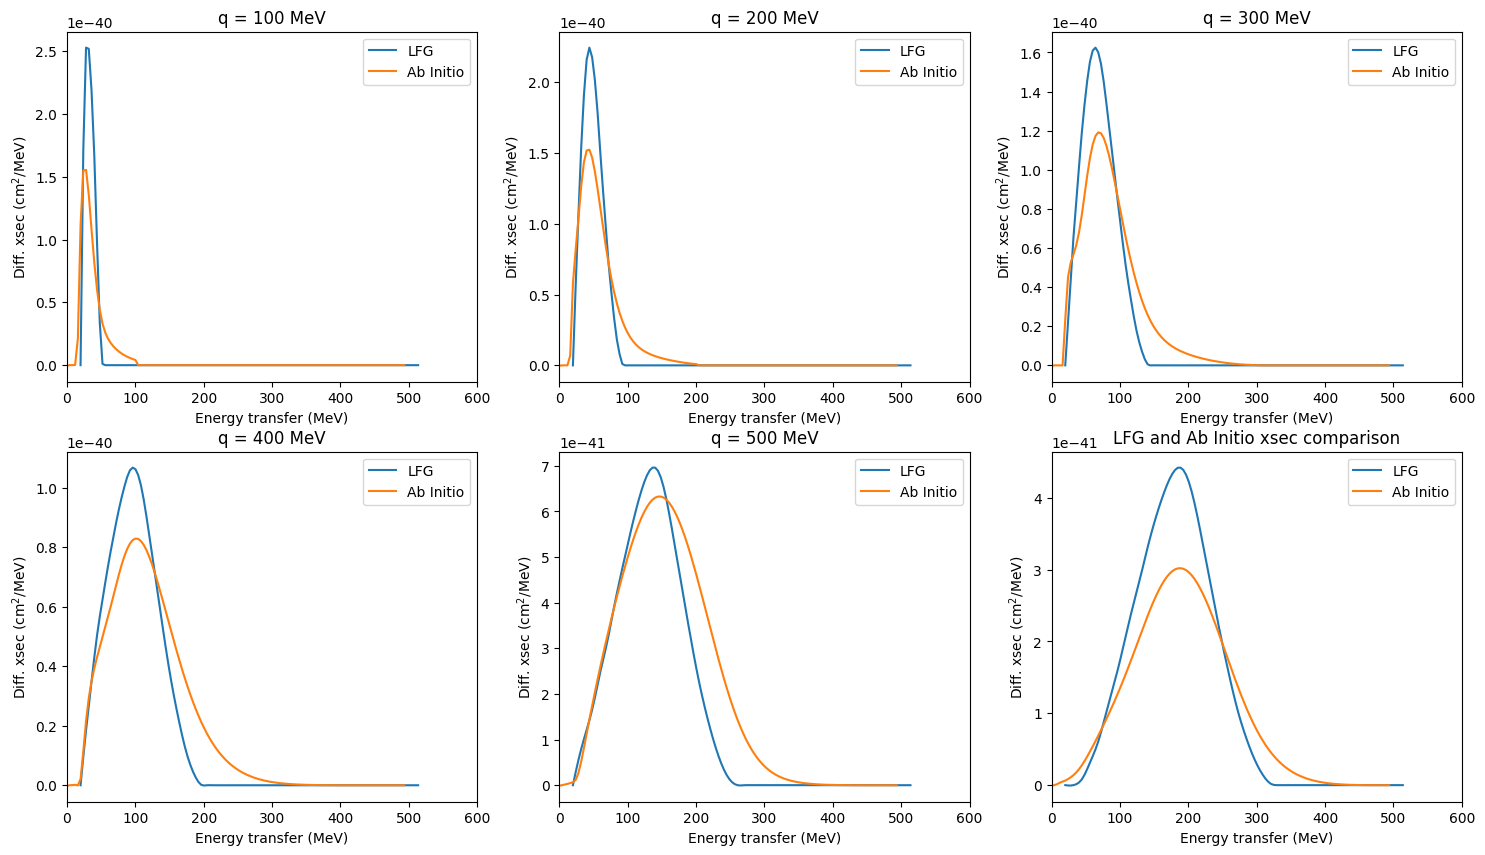

In [6]:
def plot_comparison_for_q(q, ax):
    maxval = 1200
    stepsize = 4
    steps = int(maxval/stepsize)
    qidx = int(q/stepsize)
    wvals = np.linspace(0, maxval, steps)

    for (name, model) in zip(["LFG", "Ab Initio"], [lfg, ab]):
        data = []
        lookup_vals = modules.nuwro.Stupid_2D_to_1D(qidx, np.array(range(0, steps)), steps)
        table_values = [
            model[0][lookup_vals],
            model[1][lookup_vals],
            model[2][lookup_vals],
            model[3][lookup_vals],
            model[4][lookup_vals],
        ]
        xsec = calc_xsec(q, wvals, table_values)
        offset = 0
        if name == "LFG":
            offset = 20
        ax.plot(wvals + offset, xsec, label=name)

    ax.legend()
    ax.set_xlim(0,600)

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
axs = axs.flatten()
qs = [100, 200, 300, 400, 500, 600]
for i, q in enumerate(qs):
    plot_comparison_for_q(q, axs[i])
    axs[i].set_title(f"q = {q} MeV")
    axs[i].set_xlabel("Energy transfer (MeV)")
    axs[i].set_ylabel("Diff. xsec (cm$^2$/MeV)")
plt.title("LFG and Ab Initio xsec comparison")
# plt.tight_layout()